In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

In [2]:
# Constants
v = +1 if np.random.rand() < 0.5 else -1
l1 = 500
l = 500
l2 = 1000
L = 1000
L0 = 5
p0 = 0.9

In [3]:
dist = np.arange(1,L+1)
uniform_concentration_ = np.ones(L) * L0

UIC = []

p = 0
for k in range(3):
    for j in range(1,1001):
        UIC.append(j)
    p += 0.33

In [4]:
# State function :
def get_state(position):
    return 0 if uniform_concentration_[position] >= L0 else 1

In [5]:
def qlearning(alpha , epsilon , T , concentration , initial_position , v = +1 ):
    final_position = []
    for position in initial_position:
        pos = position
        pos_old = pos
        pos_old2 = pos

        posi_ = []
        Q = np.zeros((2,2))
    
        for _ in range(T):
            state = get_state(pos - 1)
            if np.random.rand() < p0:
                action = 0
            else:
                c_l1 = concentration[pos_old - 1]
                c_l2 = concentration[pos_old2 - 1]
                if c_l1 >= c_l2:
                    cost_persist, cost_reverse = 0, 1
                elif c_l1 < c_l2:
                    cost_persist, cost_reverse = 1, 0
        
                if np.random.rand() < epsilon:
                    action = np.random.choice([0,1])
                else:
                    qvals = Q[state]
                    min_actions = np.where(qvals == qvals.min())[0]
                    action = np.random.choice(min_actions)
        
                cost = cost_persist if action == 0 else cost_reverse
                oldQ = Q[state, action]
                Q[state, action] = (1 - alpha)*oldQ + alpha * (cost)

            if action == 0:
                pos_new = (pos + v) % L
                pos_old2, pos_old = pos_old, pos
                pos = pos_new
            else:
                v = -v
     
            posi_.append(pos)
        final_position.append(posi_)
    return final_position

In [6]:
def circular_direction(a, b, max_val=999):
    if a == b:
        return 0
    forward = (b - a) % max_val
    backward = (a - b) % max_val
    return 1 if forward < backward else -1

def count_circular_turning_points(arr, max_val=999):
    arr = np.array(arr)
    if len(arr) < 2:
        return 0

    turning_points = 0
    prev_direction = 0

    for i in range(1, len(arr)):
        direction = circular_direction(arr[i-1], arr[i], max_val)
        
        if direction == 0:
            continue  # skip if no movement

        if prev_direction != 0 and direction != prev_direction:
            turning_points += 1
        prev_direction = direction

    return turning_points

In [7]:
def list_to_avg(l):
    res = []
    i = 0
    for ele in l:
        c = count_circular_turning_points(ele)
        if c == 0:
            c = 1
        res.append(len(ele) / c)
    return np.mean(res)

In [8]:
epsilons_1 = [0.001,0.01,0.05,0.1,0.2,0.4,0.6,0.8,0.9,1]

In [9]:
alpha = 0.1
mrd_1 = []
list_1 = []
for e in epsilons_1:
    T = 1000
    list_ = qlearning(alpha , e , T , uniform_concentration_ , initial_position = UIC )
    mrd_1.append(list_to_avg(list_))
    list_1.append(list_)

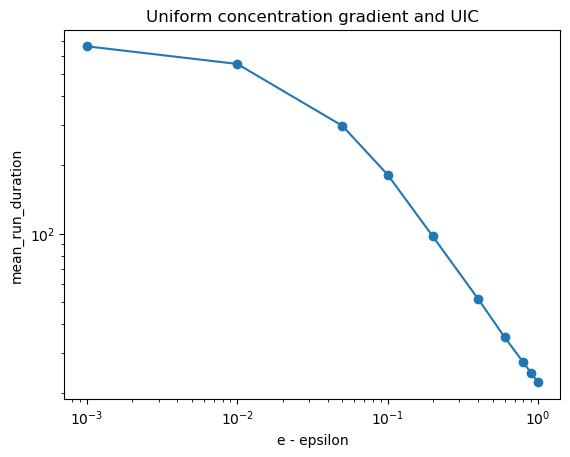

In [13]:
plt.scatter(epsilons_1 , mrd_1)
plt.xscale('log')
plt.yscale('log')
plt.plot(epsilons_1 , mrd_1)
plt.xlabel('e - epsilon')
plt.ylabel('mean_run_duration')
plt.title('Uniform concentration gradient and UIC');